## The performance of a lock complex
In this notebook, we simulate a lock object on a network. Randomly generated, evenly sized vessels sampled from an exponential distribution have to pass this lock. We add a complex lock object to the graph. Vessels are levelled in the same lock operation if they can fit inside the lock, and register with the lock operator before the start of the lock operation. Based on this behaviour, we will quantify the performance of the lock in terms of efficiency and capacity.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object, generate_vessels_from_distribution
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of utils for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.calculations import estimate_lock_capacity, calculate_lock_occupancy
from opentnsim.lock.logutils import calculate_cycle_information, get_vessel_delays

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


In [2]:
%load_ext autoreload
%autoreload 2

#### Input parameters

In [3]:
lock_length = 250. #meters
mean_interarrival_time = 30. #minutes

#### 0. Create environment

In [4]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2025, 1, 7, 0, 0, 0)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph
We create a directional graph with a layout similar to that of notebooks 0201, 0202, and 0203. However, we add two additional edges prior to nodes 0 and 1 to show that a lock can also be implemented in a larger graph. These edges are 20km long.

In [5]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))

# add edges
graph.add_edge('-1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('+1','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)

# add graph to environment
env.graph = graph

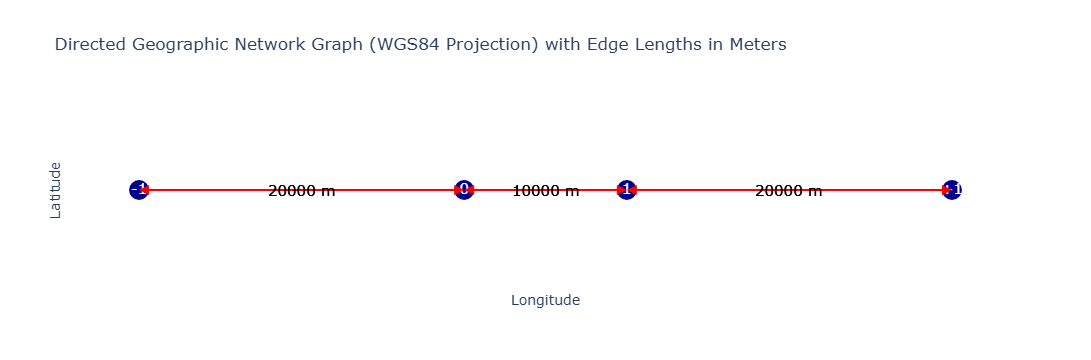

In [6]:
plot_graph(graph)

#### 1+ Adding infrastructure
We construct the same lock complex as before.

In [7]:
distance_to_crossing_point = 500

lock_chamber = IsLockChamber(env=env,
                             lock_length = lock_length,
                             lock_width = 25.,
                             lock_depth = 6,
                             sailing_distance_to_crossing_point = distance_to_crossing_point,
                             name='Lock',
                             gate_open = '0',
                             edge = ('0','1'))

In [8]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0,
                                   distance_from_edge_start = lock_chamber.distance_from_start_node_to_lock_gate_A - distance_to_crossing_point)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = lock_chamber.distance_from_end_node_to_lock_gate_B - distance_to_crossing_point)

In [9]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create the same vessel agent object.

In [10]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [11]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

To better illustrate the lock's performance, we add two vessel generators at the network boundaries. From each direction, 10 equally sized vessels are generated randomly from an exponential distribution with a mean arrival rate of 30 minutes. We use different seeds to get different arrival times.

In [12]:
upstream_vessels = generate_vessels_from_distribution(env=env,
                                                      VesselClass = Vessel,
                                                      vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                      mean_arrival_rate=30.,
                                                      number_of_vessels=5,
                                                      start_node = '-1',
                                                      end_node = '+1',
                                                      seed = 123)

downstream_vessels = generate_vessels_from_distribution(env=env,
                                                        VesselClass = Vessel,
                                                        vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                        mean_arrival_rate=30.,
                                                        number_of_vessels=5,
                                                        start_node = '+1',
                                                        end_node = '-1',
                                                        seed = 456)

vessels = upstream_vessels + downstream_vessels

for vessel in vessels:
    env.process(mission(env, vessel))

#### 3. Run simulation
We run the simulation.

In [13]:
import time as timepy
t1 = timepy.time()
env.run(until=simulation_stop.timestamp()) #0.001
t2 = timepy.time()
print(t2-t1)

0.0004475116729736328 0.024829387664794922 0.02169346809387207 4.0531158447265625e-06 0.0019490718841552734 0.009197235107421875
0.00040602684020996094 0.021970272064208984 0.004065513610839844 3.0994415283203125e-06 0.0022232532501220703 0.010664224624633789
0.00037741661071777344 0.02165508270263672 0.003156900405883789 2.384185791015625e-06 0.002057790756225586 0.00854945182800293
0.0010268688201904297 0.03424978256225586 0.003141641616821289 2.6226043701171875e-06 0.0018291473388671875 0.008226871490478516
0.00036644935607910156 0.025351524353027344 0.01857304573059082 2.384185791015625e-06 0.0019121170043945312 0.00855708122253418
0.0013148784637451172 0.033303022384643555 0.0031282901763916016 2.6226043701171875e-06 0.0018939971923828125 0.008427858352661133
0.0008804798126220703 0.0685262680053711 0.00639033317565918 4.5299530029296875e-06 0.005336761474609375 0.012858152389526367
0.0008013248443603516 0.04170370101928711 0.03801274299621582 3.0994415283203125e-06 0.002661705017

#### 4. Inspect output
Performance indicators:

##### <strong>Intensity (I)</strong>

In [14]:
lock_chamber.get_aggregated_cycle_information()['Cycle-averaged traffic intensity (I_s_avg)']

np.float64(3.18)

##### <strong>Vessel delay</strong>
Vessel delays are defined as such that the vessel speed deviates from its normal cruising speed.

In [15]:
_, _, vessel_delays_causes = get_vessel_delays(lock_chamber)
print(f'The average vessel delay is: {vessel_delays_causes['average_vessel_delay']}')

The average vessel delay is: 0 days 01:13:16


##### <strong>Lock chamber occupancy</strong>

In [16]:
occupancy, occupancy_df = calculate_lock_occupancy(lock_chamber)
print(f"The mean occupancy equals {occupancy} %")

The mean occupancy equals 57.14 %


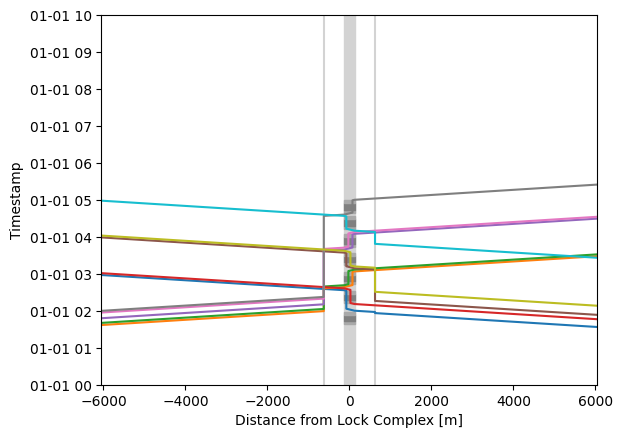

In [17]:
# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                        ylimmax = pd.Timestamp('2025-01-01 10:00:00'),
                        method='Matplotlib',
                        boundary_nodes = ['-1','+1'],
                        legend=False)